# HW02-2：房地产上市公司财务特征分析

- 姓名：黄翌珊
- 学号：24360023
- 作业简介或教师作业页面链接：[HW02 作业页面](https://lianxhcn.github.io/FinEco/exercises/hw-02.html)
- 个人 GitHub 仓库访问地址：（待填写）
- HW02-1 目录链接：（待填写）
- HW02-2 目录链接：（待填写）
- 数据来源、获取日期与样本期间：CSMAR（中山大学授权）。样本为 **2005—2015 年房地产 A 股上市公司**年度合并报表，另取 2004 年末资产负债表计算平均资产/权益。资产负债表/利润表/股权性质文件/基本信息年度表分两段下载：2004—2013 段（2026-09-20 下载）、2014—2025 段（2026-09-16 下载）。
- AI 使用声明：使用了 WorkBuddy（AI 助手）辅助编写数据清洗管线与 Notebook 代码初稿；本人核验了字段口径、行业映射与图表结果。

**分析目的与总体思路**：构建 2005—2015 年房地产 A 股上市公司的企业—年度非平衡面板（按各年年末上市状态、行业与产权属性），回答三个问题：(1) 样本期内房地产公司数量与国有/民营产权结构如何演变；(2) 资产负债率、银行借款占比、短期负债占比、ROA、ROE、现金持有六个财务指标的时间趋势如何；(3) 国有与民营企业的财务特征有何差异。描述性差异不解释为产权的因果作用。

## 1. 数据来源、样本构建与样本处理表

### Step 1：分析说明

- **数据表**：资产负债表（合并报表，年末）、利润表（合并报表，年末）、中国上市公司股权性质文件（年末）、上市公司基本信息年度表（年末），均来自 CSMAR；
- **样本构建**：以年度信息表**各年年末**的行业代码与上市状态为准确定样本——2011 年及以前按证监会 2001 版行业（J 门类房地产 `J01` 前缀），2012 年起按证监会 2012 版（`K70` 房地产业）；**不使用当前行业或当前上市状态回溯历史**，允许上市、退市、行业与产权跨年变化，构成非平衡面板；
- **产权分类**：按**当年**股权性质文件的实际控制人/股权性质：国企→国有，民营→民营，外资与其他→其他，缺失→不明；非国有不直接等于民营；
- **主键**：（公司代码, 年度）；单位：财务报表原始字段为人民币元，比率为无量纲。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Hiragino Sans GB', 'PingFang SC', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('data/processed/panel.csv', dtype={'code': str})
pipeline = pd.read_csv('data/processed/sample-pipeline.csv')

print('== 面板年份覆盖与完整性 ==')
years = sorted(df['year'].unique())
print('覆盖年份:', years)
need = set(range(2005, 2016))
missing = sorted(need - set(years))
print('缺失年份:', missing if missing else '无（2005-2015 完整）✓')
assert not missing, '请先按 data/README.md 补齐 CSMAR 数据并重跑 prepare_data.py'

print(f'\n样本: 2005-2015 年，{df["code"].nunique()} 家公司，{len(df)} 个公司-年度观测')
print('主键 (公司,年度) 重复:', df.duplicated(['code', 'year']).sum(), '✓' if not df.duplicated(['code', 'year']).any() else '需回查')
print('\n== 样本处理表（下载→筛选→合并→构造各阶段数量）==')
pipeline

== 面板年份覆盖与完整性 ==
覆盖年份: [np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]
缺失年份: 无（2005-2015 完整）✓

样本: 2005-2015 年，175 家公司，1190 个公司-年度观测
主键 (公司,年度) 重复: 0 ✓

== 样本处理表（下载→筛选→合并→构造各阶段数量）==


,处理阶段,数量
0,原始资产负债表记录（全部类型、全部报告期）,628162
1,筛选：合并报表(Typrep=A) 且 年末(12-31),71111
2,"主键 (公司,年末) 重复记录",0
3,筛选：利润表 合并报表 年末记录,71111
4,年度信息表中 房地产 公司-年度记录（按各年年末行业与上市状态）,2386
5,合并财报后 公司-年度观测（面板全集）,2386
6,其中缺失当年资产负债表的观测,7
7,样本截取 2005-2015 后 公司-年度观测,1190


### Step 3：结果解读

样本处理表显示从原始数据到最终面板的各级数量：原始资产负债表记录 **628,162** 条（全部报告期、含母公司报表）→ 筛选合并报表（Typrep=A）且年末（12-31）后剩 **71,111** 条 → 年度信息表中按各年年末行业与上市状态界定为房地产的公司-年度记录 **2,386** 条（2004—2025 全跨度）→ 截取 2005—2015 年后得到 **1,190** 个公司-年度观测、**175** 家公司。主键（公司,年度）无重复；2005—2015 年逐年均有观测，**面板完整无缺失年份**。仅有 7 条观测缺失当年资产负债表（多为长期停牌公司），占比不足 0.6%。

两段下载的数据在 (公司,年末) 主键上无重复、无缺口，说明 2004—2013 与 2014—2015 两段拼接成功。

## 2. 公司数量与产权结构

### Step 1：分析说明

按各年年末状态统计：房地产上市公司**总数**；国有、民营、其他、产权**不明**公司数量；国有与民营占当年总数的比例。公司数按年代码去重，不因财务指标缺失而剔除。存在其他/不明类别时，国有+民营占比之和可以小于 100%。

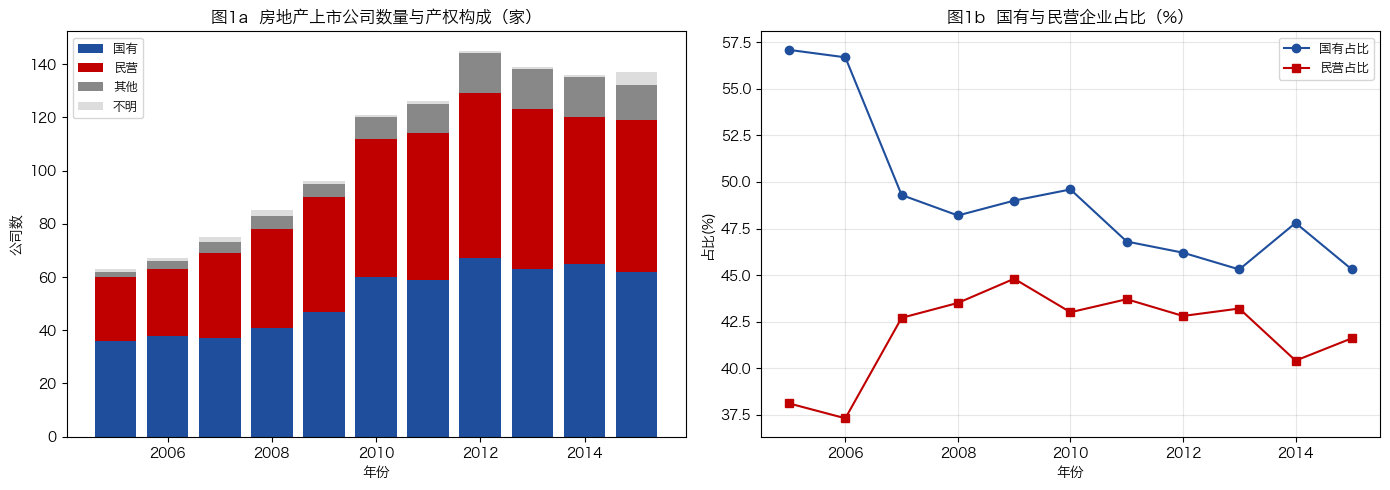

,总数,国有,民营,其他,不明,国有占比(%),民营占比(%)
year,,,,,,,
2005,63,36,24,2,1,57.1,38.1
2006,67,38,25,3,1,56.7,37.3
2007,75,37,32,4,2,49.3,42.7
2008,85,41,37,5,2,48.2,43.5
2009,96,47,43,5,1,49.0,44.8
2010,121,60,52,8,1,49.6,43.0
2011,126,59,55,11,1,46.8,43.7
2012,145,67,62,15,1,46.2,42.8
2013,139,63,60,15,1,45.3,43.2


In [2]:
cnt = df.groupby('year')['code'].nunique().rename('总数')
own = df.groupby(['year', 'ownership'])['code'].nunique().unstack(fill_value=0)
for col in ['国有', '民营', '其他', '不明']:
    if col not in own.columns: own[col] = 0
own = own[['国有', '民营', '其他', '不明']]
tbl = pd.concat([cnt, own], axis=1)
tbl['国有占比(%)'] = (tbl['国有'] / tbl['总数'] * 100).round(1)
tbl['民营占比(%)'] = (tbl['民营'] / tbl['总数'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
bottom = np.zeros(len(tbl))
for col, c in zip(['国有', '民营', '其他', '不明'], ['#1f4e9c', '#c00000', '#888888', '#dddddd']):
    ax.bar(tbl.index, tbl[col], bottom=bottom, label=col, color=c)
    bottom += tbl[col].values
ax.set_title('图1a  房地产上市公司数量与产权构成（家）', fontsize=12)
ax.set_xlabel('年份'); ax.set_ylabel('公司数'); ax.legend(fontsize=9)
ax2 = axes[1]
ax2.plot(tbl.index, tbl['国有占比(%)'], 'o-', color='#1f4e9c', label='国有占比')
ax2.plot(tbl.index, tbl['民营占比(%)'], 's-', color='#c00000', label='民营占比')
ax2.set_title('图1b  国有与民营企业占比（%）', fontsize=12)
ax2.set_xlabel('年份'); ax2.set_ylabel('占比(%)'); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figs/fig1-counts-ownership.png', dpi=150, bbox_inches='tight')
plt.show()
tbl

### Step 3：结果解读

**(1) 总数演变**：房地产上市公司总数从 2005 年的 **63 家**持续增长至 2012 年的 **145 家**（峰值），2013—2015 年稳定在 136—139 家。扩张最快的阶段是 2009—2012 年（96→145 家，三年净增约 50 家），与"四万亿"后地产行业景气、大量企业借壳或转型进入房地产的背景一致；2012 年证监会暂停房地产 IPO 与再融资审批后，数量增长基本停滞。

**(2) 产权结构**：国有占比由 2005 年的 **57.1%** 逐步回落至 2015 年的 **45.3%**，民营占比同期由 **38.1%** 升至 **41.6%**，2007—2008 年前后两类占比基本持平（约 49%/43%）。整体呈"国退民进"的渐进格局，但国有房企始终占据相对多数。

**(3) 其他/不明类别**：外资等"其他"类从 2005 年的 2 家增至 2015 年的 13 家（占比约 10%），故国有+民营占比之和各年均在 85%—95% 之间、小于 100%；"不明"类各年仅 1—5 家，为股权性质披露缺失所致。

## 3. 指标质量检查：零分母、负权益与极端比率

### Step 1：分析说明

处理规则（均保留记录、不缩尾，仅将影响比率的观测记为缺失并计数）：

- **零/负分母**：总资产 ≤ 0 → 资产负债率与 Cash_TA 记缺失；总负债 ≤ 0 → bankloan 与短期负债占比记缺失；
- **负权益**：平均所有者权益 ≤ 0（资不抵债）→ ROE 记缺失（此时 ROE 无经济意义：亏损除以负权益会得到"为正"的假象）；
- **bankloan 分母口径**：短期与长期借款两个字段均非缺失才计算（缺失不按零处理）；
- **极端比率**：资产负债率 > 1（资不抵债）、|ROE| > 1 等观测保留并逐一计数说明，可能来自真实财务困境（如 ST 公司），不删除。

In [3]:
n_obs = len(df)
checks = pd.DataFrame({
    '有效观测数': df[['lev', 'bankloan', 'st_liab_ratio', 'roa', 'roe', 'cash_ta']].notna().sum(),
    '缺失数': df[['lev', 'bankloan', 'st_liab_ratio', 'roa', 'roe', 'cash_ta']].isna().sum(),
})
print(f'总观测: {n_obs}')
print(checks.to_string())
print('\n极端观测（保留，不缩尾）:')
print(f'  资产负债率 > 1（资不抵债）: {(df["lev"] > 1).sum()} 条')
if (df['lev'] > 1).any():
    print(df.loc[df['lev'] > 1, ['code', 'year', 'lev', 'total_asset']].round(3).to_string(index=False))
print(f'  平均权益 ≤ 0 导致 ROE 缺失: {((df["avg_eq"] <= 0) & df["avg_eq"].notna()).sum()} 条')
print(f'  |ROE| > 1: {(df["roe"].abs() > 1).sum()} 条')
print(f'  bankloan 两字段缺失导致无法计算: {(df["st_loan"].isna() | df["lt_loan"].isna()).sum()} 条')

总观测: 1190
               有效观测数  缺失数
lev             1183    7
bankloan        1181    9
st_liab_ratio   1183    7
roa             1174   16
roe             1157   33
cash_ta         1183    7

极端观测（保留，不缩尾）:
  资产负债率 > 1（资不抵债）: 18 条
  code  year    lev  total_asset
000007  2007  1.011 7.371829e+08
000007  2008  1.123 6.106504e+08
000007  2009  1.150 3.632716e+08
000056  2012  1.202 2.006481e+09
000505  2015  1.136 1.714444e+09
000592  2005  2.723 2.530683e+08
000592  2006  2.937 2.694375e+08
000592  2007  1.811 1.765651e+08
200770  2012  1.765 1.623377e+09
600053  2005  1.653 1.580291e+08
600603  2005  7.788 6.355609e+07
600603  2006  4.045 1.266404e+08
600603  2007  9.765 3.472427e+07
600603  2008 18.141 1.594089e+07
600603  2009 55.409 4.963990e+06
600603  2010  8.642 3.602882e+07
600766  2010  1.075 4.430132e+08
600766  2011  1.077 5.093952e+08
  平均权益 ≤ 0 导致 ROE 缺失: 17 条
  |ROE| > 1: 8 条
  bankloan 两字段缺失导致无法计算: 9 条


### Step 3：结果解读

**有效样本量**：资产负债率、短期负债占比、货币资金/总资产各有 1,183 条有效观测（缺失 7 条，即缺失当年资产负债表的观测）；ROA 缺失 16 条（另需上年资产负债表算平均资产）；ROE 缺失 33 条（其中 17 条因平均权益 ≤ 0 记缺失，其余为权益或利润缺失）；bankloan 缺失 9 条（短期或长期借款单字段缺失，不按零处理）。各指标缺失率均不足 3%。

**资不抵债（lev > 1）**：共 **18 条**观测，集中在少数长期困境公司：\*ST 零七（000007，2007—2009 连续三年）、\*ST 珠江/退市公司（000592，2005—2007）、\*ST 九章/园城类型（600603 连续 6 年，2009 年杠杆高达 55 倍）、以及 000056、000505、200770、600766 等个别年份。这些观测**保留不删**——它们反映真实的财务困境，剔除会低估行业尾部风险；但正是它们把 2009 年资产负债率**均值**拉高到 1.18，而同年**中位数**仅约 0.60，均值—中位数巨大缺口提示分布严重右偏（少数极端高杠杆公司拉动均值）。

**|ROE| > 1**：仅 8 条，多为微权益（资不抵债后权益接近零）导致的比率爆炸，中位数口径基本不受影响。总体上，缺失与极端值均为口径处理与真实困境的透明呈现，而非数据错误。

## 4. 六个财务指标：时序与产权分组比较

### Step 1：分析说明

对六个指标分别呈现：

1. **全部房地产企业历年均值与中位数**（企业比率的算术平均，非行业汇总值之比）；
2. **国有与民营企业历年均值比较**；
3. **国有与民营企业历年中位数比较**；
4. **各指标年度有效样本量表**。

均值受极端值影响，中位数更稳健，两者并置可识别分布偏斜与离群值影响；国有—民营差异为描述性对比，不代表产权的因果效应。

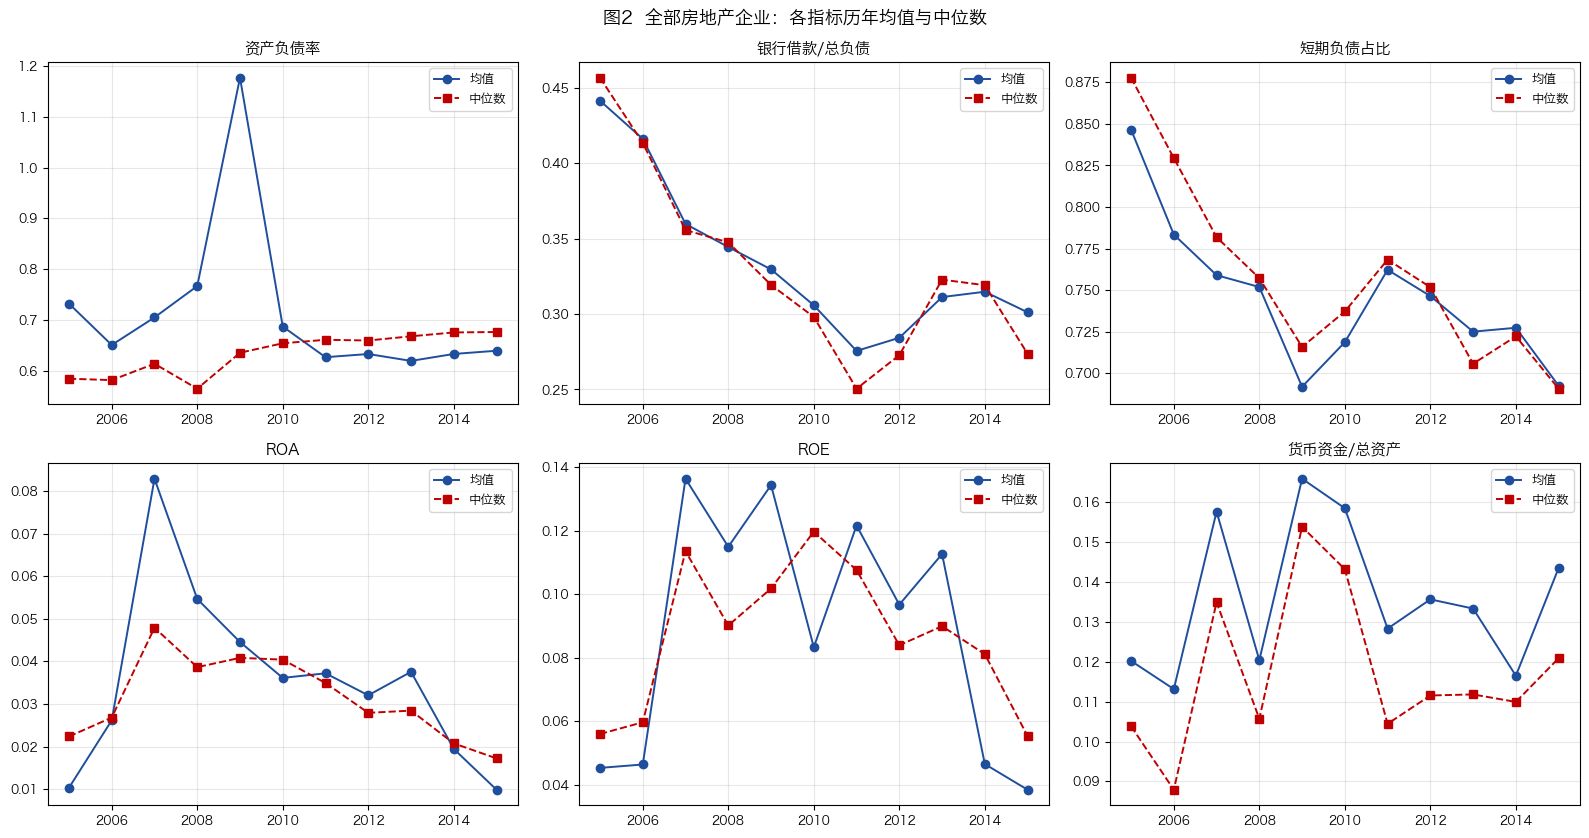

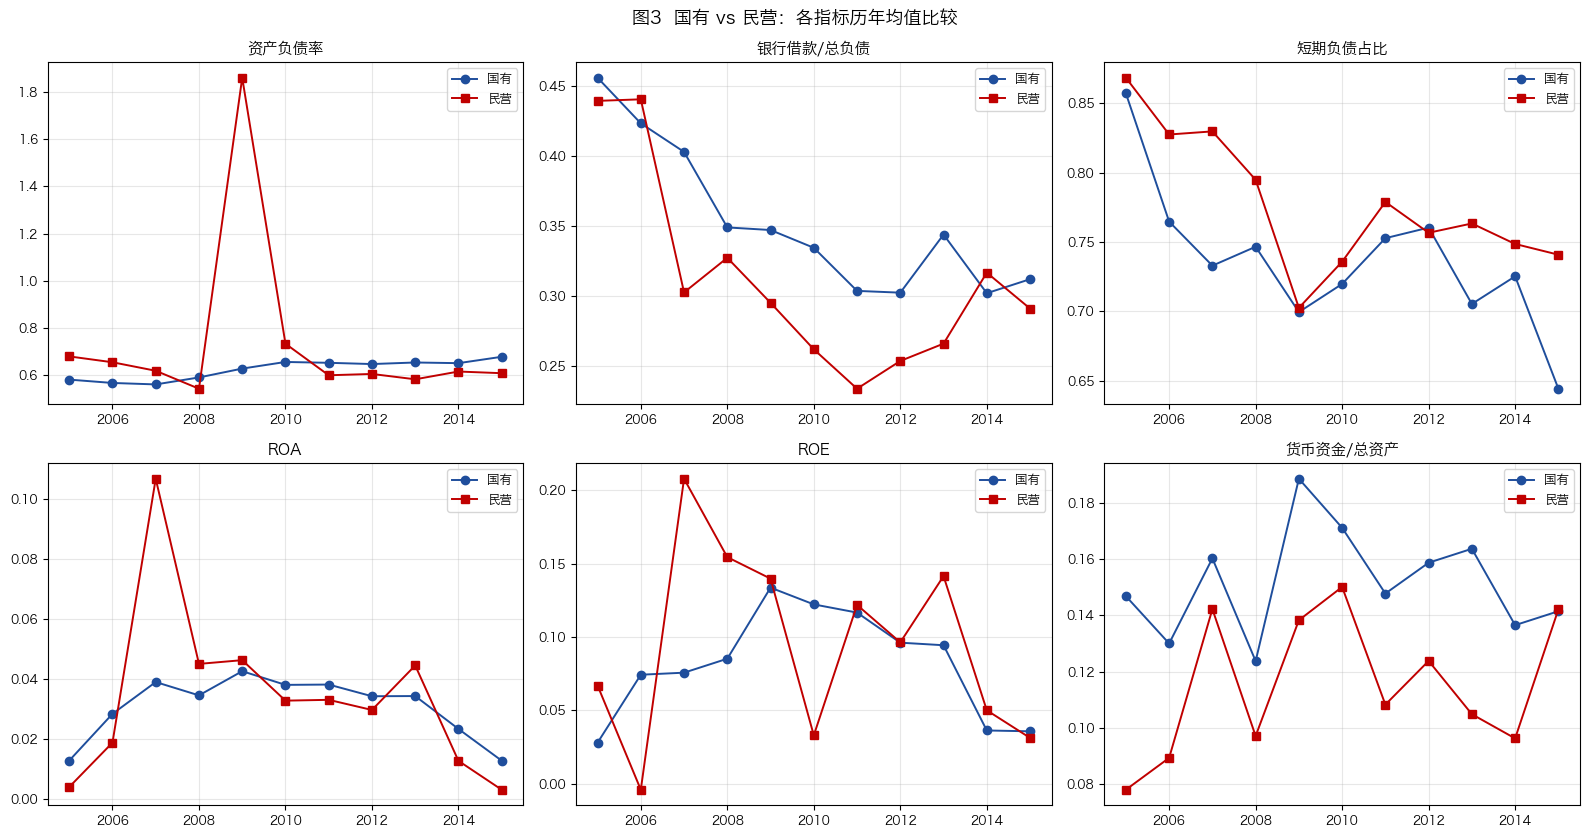

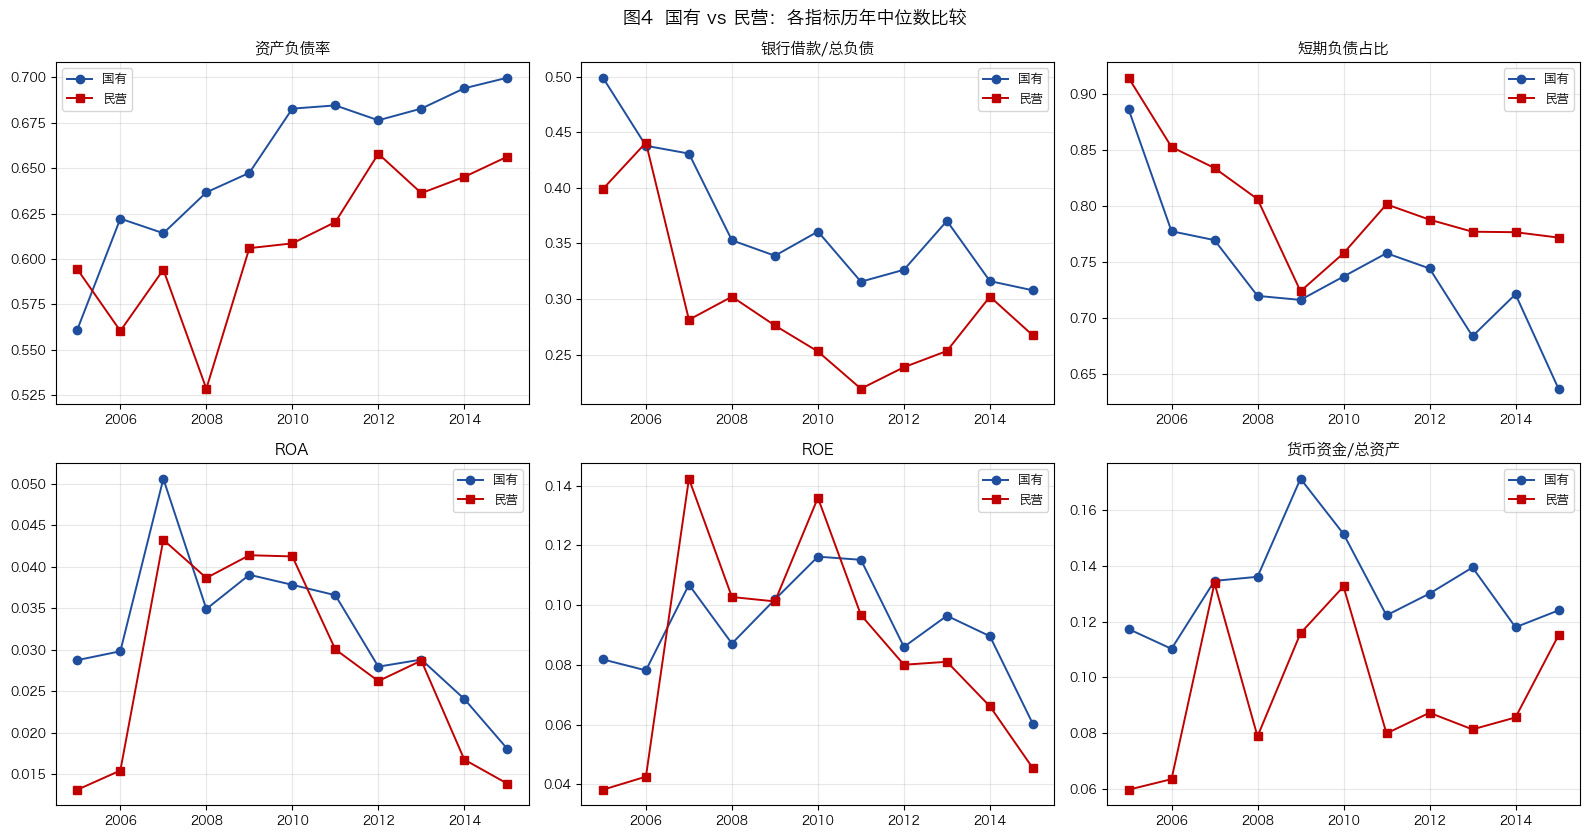

,资产负债率,银行借款/总负债,短期负债占比,ROA,ROE,货币资金/总资产
year,,,,,,
2005,63,63,63,63,60,63
2006,67,67,67,65,63,67
2007,75,75,75,72,70,75
2008,85,84,85,84,82,85
2009,96,96,96,95,93,96
2010,121,121,121,121,120,121
2011,126,125,126,126,125,126
2012,145,145,145,145,142,145
2013,139,139,139,139,139,139


In [4]:
INDS = [('lev', '资产负债率'), ('bankloan', '银行借款/总负债'), ('st_liab_ratio', '短期负债占比'),
        ('roa', 'ROA'), ('roe', 'ROE'), ('cash_ta', '货币资金/总资产')]

# 4.1 全样本均值与中位数
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
for ax, (col, label) in zip(axes.ravel(), INDS):
    g = df.groupby('year')[col]
    ax.plot(g.mean().index, g.mean().values, 'o-', lw=1.4, color='#1f4e9c', label='均值')
    ax.plot(g.median().index, g.median().values, 's--', lw=1.4, color='#c00000', label='中位数')
    ax.set_title(label, fontsize=11); ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.tick_params(labelsize=9)
fig.suptitle('图2  全部房地产企业：各指标历年均值与中位数', fontsize=13)
plt.tight_layout()
plt.savefig('figs/fig2-all-mean-median.png', dpi=150, bbox_inches='tight')
plt.show()

# 4.2 国有 vs 民营：均值
sub = df[df['ownership'].isin(['国有', '民营'])]
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
for ax, (col, label) in zip(axes.ravel(), INDS):
    g = sub.groupby(['year', 'ownership'])[col].mean().unstack()
    ax.plot(g.index, g['国有'], 'o-', lw=1.4, color='#1f4e9c', label='国有')
    ax.plot(g.index, g['民营'], 's-', lw=1.4, color='#c00000', label='民营')
    ax.set_title(label, fontsize=11); ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.tick_params(labelsize=9)
fig.suptitle('图3  国有 vs 民营：各指标历年均值比较', fontsize=13)
plt.tight_layout()
plt.savefig('figs/fig3-own-mean.png', dpi=150, bbox_inches='tight')
plt.show()

# 4.3 国有 vs 民营：中位数
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
for ax, (col, label) in zip(axes.ravel(), INDS):
    g = sub.groupby(['year', 'ownership'])[col].median().unstack()
    ax.plot(g.index, g['国有'], 'o-', lw=1.4, color='#1f4e9c', label='国有')
    ax.plot(g.index, g['民营'], 's-', lw=1.4, color='#c00000', label='民营')
    ax.set_title(label, fontsize=11); ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.tick_params(labelsize=9)
fig.suptitle('图4  国有 vs 民营：各指标历年中位数比较', fontsize=13)
plt.tight_layout()
plt.savefig('figs/fig4-own-median.png', dpi=150, bbox_inches='tight')
plt.show()

# 4.4 年度有效样本量表
n_tbl = df.groupby('year')[['lev', 'bankloan', 'st_liab_ratio', 'roa', 'roe', 'cash_ta']].count()
n_tbl.columns = [label for _, label in INDS]
n_tbl

### Step 3：结果解读

**杠杆结构（lev / bankloan / st_liab_ratio）**

- **资产负债率**：均值 2005 年 73.2% → 2013 年 62.0%（低点）→ 2015 年 64.0%；中位数同期由 58.5% 升至 67.7%。均值在 2008—2009 年畸高（76.7%→117.7%），完全由少数资不抵债公司拉动（2009 年中位数仅约 60%），均值—中位数最大差约 57 个百分点，说明杠杆分布右偏、尾部风险集中在极少数困境公司。中位数口径下行业杠杆整体小幅上行，未出现普遍失控。
- **银行借款/总负债（bankloan）**：均值从 2005 年 44.1% 一路降至 2015 年 30.1%（中位数 45.7%→27.4%），谷值出现在 2011 年（27.6%）。行业融资结构明显从银行信贷转向经营性负债（预售房款、应付款）与多元融资渠道，与预售制度扩张和 2010 年后银行对地产开发贷收紧一致。
- **短期负债占比**：由 2005 年 84.7%（均值）降至 2009 年 69.2% 后窄幅波动，2015 年 69.2%。负债期限结构整体短化但样本后期趋稳，高短期占比（约七成）与房企"滚动开发、以销定产"的商业模式吻合，同时隐含期限错配与流动性风险。

**盈利能力（ROA / ROE / cash_ta）**

- **ROA**：2007 年 8.3% 见顶后趋势性回落，2014—2015 年快速滑落至 1.9%→**1.0%**（样本期最低）。2015 年 ROA 均值已低于 2005 年，反映行业利润率被地价上涨与库存积压系统性压缩。
- **ROE**：2007 年 13.6%、2009 年 13.4% 双峰，2015 年降至 3.9%。各年 ROE 均显著高于 ROA（如 2015 年 3.9% vs 1.0%），杠杆对股东回报的放大效应约为 4 倍，但到样本末期"加杠杆赚利润"的模式已难以为继——ROE 与 ROA 同步塌陷说明是盈利基本面而非杠杆约束成为瓶颈。
- **货币资金/总资产**：均值 12%—16.6% 之间波动，2009 年 16.6% 为峰值（"四万亿"宽松后房企回笼加速），2015 年 14.4% 仍处较高水平，账面现金充裕与利润下滑并存，与库存高企、开工放缓下资金滞留在账的特征一致。

**国有 vs 民营**

- **融资与流动性**：国企 bankloan 各年均高于民企（2012 年 30.2% vs 25.3%）、cash_ta 也更高（2012 年 15.9% vs 12.4%），与国企融资约束更松、银行信贷与授信资源倾斜的既有文献一致；民企 2015 年短期负债占比（74.1%）反而高于国企（64.4%），期限结构更脆弱。
- **盈利**：两类企业 ROA/ROE 均值差距很小（如 2015 年 ROE 3.6% vs 3.1%），产权并未带来系统性盈利差异。
- **谨慎解读**：2009 年民企资产负债率均值畸高（186.0%）源于当年民企组内多家资不抵债公司，属离群值驱动而非群体性加杠杆。上述差异均为**描述性对比**：国企多为大型上市房企（样本选择）、行业周期与政策环境都是混杂因素，不能解释为产权的因果作用。

**突变归因检查**：资产负债率 2008—2009 年均值突变、民企组 2009 年畸高，均已被第 3 节计数的资不抵债观测（\*ST 零七、\*ST 珠江、600603 等）解释，属于极端观测而非口径错误；bankloan 与短期负债占比的平滑下行则对应 2010 年后开发贷收紧与预售资金占比上升，属真实结构性变化。

## 5. 总体结论

**(1) 行业规模与产权结构**：2005—2015 年房地产 A 股上市公司从 63 家增至 137 家，扩张集中在 2009—2012 年（"四万亿"后借壳与转型潮），2012 年地产 IPO 暂停后进入平台期。产权上呈渐进式"国退民进"：国有占比由 57.1% 降至 45.3%，民营由 38.1% 升至 41.6%，但国有房企始终占相对多数，外资等其他类约占 10%。

**(2) 财务结构的两条主线**：一是**融资去银行化**——银行借款占总负债的比重从 44.1% 降至 30.1%，行业转向预售房款与经营性负债驱动，短期负债占比稳定约七成，期限错配风险内生存在；二是**盈利系统性塌陷**——ROA 从 2007 年峰值 8.3% 跌至 2015 年 1.0%，ROE 从 13.6% 跌至 3.9%，杠杆放大效应（ROE≈4×ROA）在盈利基本面恶化面前失效，"高杠杆赚利润"模式走到尽头，恰好对应 2015 年行业去库存压力与随后的政策转向。

**(3) 分布特征重于均值**：资产负债率的均值（2009 年 117.7%）与中位数（约 60%）严重背离，全部可由 18 条资不抵债观测解释；行业的真实杠杆中枢（中位数）是平稳小幅上行的。这提示分析公司财务数据时**均值极易被尾部扭曲**，中位数与极端值计数必须并列报告。

**(4) 国有—民营差异在融资渠道而非盈利**：国企银行信贷依赖度更高、现金更充裕、期限结构更稳，民企反之；但两类企业盈利能力无系统差异。这与融资约束/软预算约束文献的描述性证据一致，但因样本选择、周期与政策混杂，不能作因果解释。

**关键处理判断与局限**：本面板为非平衡面板（年末口径、175 家公司、1,190 个公司-年度观测）；借款单字段缺失不按零处理；平均权益 ≤ 0 时 ROE 记缺失；资不抵债等极端值保留并计数。局限包括：CSMAR 年末口径受会计政策变更影响（如 2007 年新准则切换）、产权分类依赖股权性质披露质量（"不明"类每年 1—5 家）、两段下载拼接可能遗漏极个别退市公司记录、描述性分析无法识别因果。以上局限不推翻方向性结论，但具体数值解释需保留弹性。